# Kalman-Filtered Dynamic Hedge Ratio Pairs Trading — ES/NQ

**Research question:** is "SMT divergence" — the retail trading claim that correlated
index futures (ES, NQ) diverging predicts a reversal — a real, tradeable statistical
phenomenon once formalised rigorously, rather than an eyeballed chart pattern?

**Approach:** cointegration &rarr; time-varying hedge ratio via a Kalman filter &rarr;
honest out-of-sample (walk-forward) backtesting &rarr; bootstrap significance testing
&rarr; parameter robustness checks &rarr; a multi-pair generalisation test.

**Headline finding:** the Kalman-filtered strategy shows a modest, borderline-
significant edge under honest out-of-sample testing on ES/NQ (Sharpe 0.31, bootstrap
p&approx;0.08), but that edge does **not** clearly generalise to two other related
pairs tested under the same fixed methodology (Section 12). This is **not** a
blockbuster result, and it isn't a clean confirmation either — both are intended,
reported findings, not shortfalls. The goal throughout was a rigorous test of a
retail claim, not a guaranteed profit or a tidy story.

*This notebook is fully self-contained: every design decision and its justification
is written out inline, closest to the step it belongs to. It calls directly into the
`src/` modules rather than duplicating their logic, so the code here and the code
actually used for the analysis never drift apart.*

In [1]:
%matplotlib inline
import sys, os

# Absolute path, not inferred from wherever the kernel happened to start --
# directory-climbing logic can't work if the kernel's start directory isn't even
# inside this project's folder tree.
PROJECT_ROOT = r"c:\Users\Chia Jia Lin\Desktop\Projects\Kalman filter pairs trading hedge ratio"
os.chdir(PROJECT_ROOT)
SRC_PATH = os.path.join(PROJECT_ROOT, "src")
if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

pd.set_option("display.precision", 4)

## 1. The Pair: ES and NQ Continuous Futures

ES (S&P 500 E-mini) and NQ (Nasdaq-100 E-mini) daily OHLCV, sourced from Yahoo
Finance. Both indices are tech-correlated, which is exactly why SMT traders pair
them — and why any genuine divergence between them is expected to be small and
short-lived, not obvious.

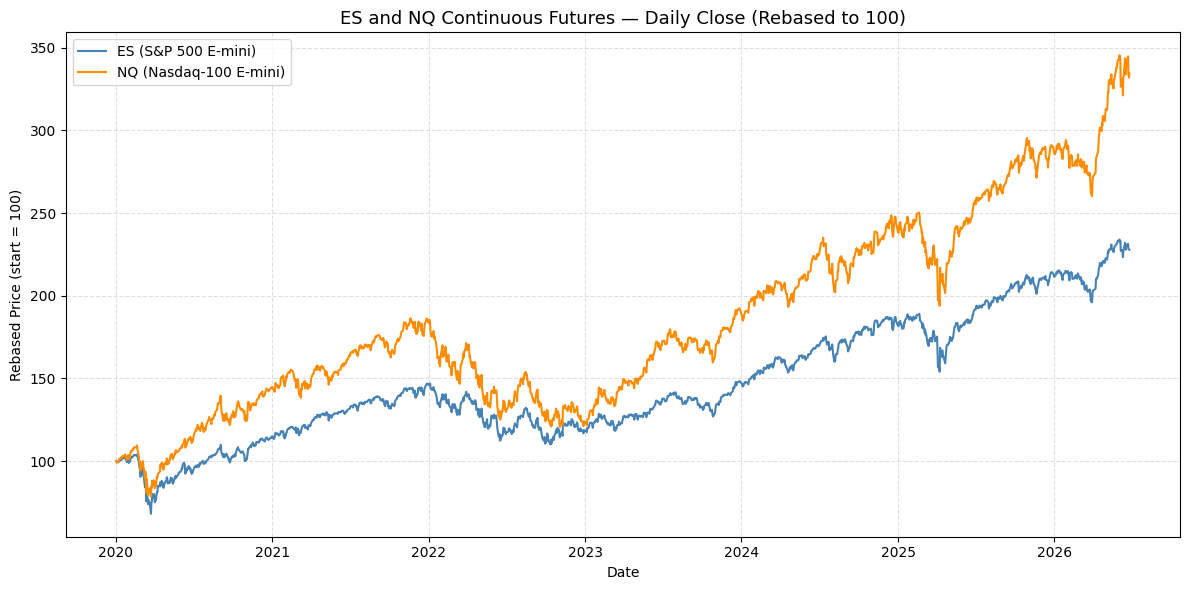

1631 trading days: 2020-01-02 to 2026-06-25


In [2]:
from rebased_plot import load_prices, plot_rebased_prices

es, nq = load_prices("data/raw")
plot_rebased_prices(es, nq)

es_log = np.log(es["close"])
nq_log = np.log(nq["close"])
print(f"{len(es_log)} trading days: {es_log.index.min().date()} to {es_log.index.max().date()}")

## 2. Is There a Tradeable Relationship? (Cointegration)

Correlation between ES and NQ returns isn't enough to build a spread trade — a
well-defined, mean-reverting spread requires a *stable long-run level
relationship*, which is what cointegration (not correlation) actually tests for.

**Step 1 — confirm both series are I(1).** Augmented Dickey-Fuller test (H0: unit
root / non-stationary) on log price levels (expect fail-to-reject) and log returns
(expect reject).

In [3]:
from stationary import run_adf

print("Log levels (expect non-stationary):")
run_adf(es_log, "ES log price")
run_adf(nq_log, "NQ log price")

print("\nLog returns, first difference (expect stationary):")
run_adf(es_log.diff(), "ES log return")
_ = run_adf(nq_log.diff(), "NQ log return")  # assign to suppress the auto-displayed dict

Log levels (expect non-stationary):

--- ES log price ---
  ADF statistic : -0.5515
  p-value       : 0.8816
  Critical values:
    1%: -3.434  ([fail to reject] at this level)
    5%: -2.863  ([fail to reject] at this level)
    10%: -2.568  ([fail to reject] at this level)



--- NQ log price ---
  ADF statistic : -0.6333
  p-value       : 0.8633
  Critical values:
    1%: -3.434  ([fail to reject] at this level)
    5%: -2.863  ([fail to reject] at this level)
    10%: -2.568  ([fail to reject] at this level)

Log returns, first difference (expect stationary):

--- ES log return ---
  ADF statistic : -12.6828
  p-value       : 0.0000
  Critical values:
    1%: -3.434  ([reject] at this level)
    5%: -2.863  ([reject] at this level)
    10%: -2.568  ([reject] at this level)

--- NQ log return ---
  ADF statistic : -12.9685
  p-value       : 0.0000
  Critical values:
    1%: -3.434  ([reject] at this level)
    5%: -2.863  ([reject] at this level)
    10%: -2.568  ([reject] at this level)


Both series are confirmed I(1) — non-stationary in levels, stationary after one
difference. This is the precondition for the Engle-Granger cointegration test below
to be valid.

**Step 2 — regress and test the residual.** `log(NQ) = alpha + beta * log(ES) + spread`.
If the residual spread is itself stationary, the two series are cointegrated: they
share a stable long-run relationship even though each wanders individually.

In [4]:
from cointegration import fit_ols

fit = fit_ols(nq_log, es_log)
beta, alpha, spread = fit["beta"], fit["alpha"], fit["spread"]
print(f"beta (hedge ratio) = {beta:.4f}")
print(f"alpha (intercept)  = {alpha:.4f}")

adf_spread = run_adf(spread, "Spread (NQ log price - ES log price)")

beta (hedge ratio) = 1.2384
alpha (intercept)  = -0.7949

--- Spread (NQ log price - ES log price) ---
  ADF statistic : -3.1080
  p-value       : 0.0260
  Critical values:
    1%: -3.434  ([fail to reject] at this level)
    5%: -2.863  ([reject] at this level)
    10%: -2.568  ([reject] at this level)


Result: reject the unit-root null at 5% and 10%, fail to reject at 1% (p &approx; 0.026).
**Honest read: cointegration is real but not overwhelmingly strong** — good enough to
proceed, worth stating plainly rather than oversold.

## 3. How Fast Does the Spread Revert? (Ornstein-Uhlenbeck Fit)

Knowing the spread is stationary isn't enough to design a trading rule — the
reversion *speed* sets the natural lookback window for z-scoring it. The OU process
`dX_t = theta*(mu - X_t)dt + sigma*dW_t` is fit via an AR(1) regression on the spread:
`X_t = c + phi*X_{t-1} + eps`, with `theta = -log(phi)` and `half_life = log(2)/theta`.

In [5]:
from ou_model import estimate_ou, half_life

ou_params = estimate_ou(spread)
hl = half_life(ou_params["theta"])
print(f"theta (reversion speed) : {ou_params['theta']:.4f}")
print(f"mu    (long-run mean)   : {ou_params['mu']:.6f}")
print(f"sigma (spread vol)      : {ou_params['sigma']:.6f}")
print(f"half-life               : {hl} days")

theta (reversion speed) : 0.0101
mu    (long-run mean)   : 0.011360
sigma (spread vol)      : 0.005780
half-life               : 68 days


## 4. First Backtest: Static Hedge Ratio

Rolling z-score of the spread (window = the half-life above), entry at |z| > 2, exit
at z crossing 0, 1bp one-way transaction cost. This first pass uses the *static* OLS
beta from Section 2 — fixed for the entire backtest period.

In [6]:
from backtest import (
    build_spread, zscore, generate_signals, compute_returns, compute_metrics,
    ENTRY_THRESHOLD, EXIT_THRESHOLD, COST_BPS,
)

z_static = zscore(spread, hl)
pos_static = generate_signals(z_static, ENTRY_THRESHOLD, EXIT_THRESHOLD)
ret_static = compute_returns(pos_static, nq_log, es_log, beta, COST_BPS)

print("=== Naive full-sample backtest: Static OLS ===")
metrics_static = compute_metrics(ret_static, pos_static)

=== Naive full-sample backtest: Static OLS ===
Annualised Sharpe : -0.0506
Max Drawdown      : -0.1761
Hit Rate          : 0.5027
Annual Turnover   : 7.6 round trips


**Verdict: bad.** A fixed hedge ratio doesn't track a relationship that drifts (e.g.
sector rotation between tech-heavy NQ and broader-market ES). This motivates the next
question: how do you track a hedge ratio that changes over time, and trade that
change, in a statistically principled way?

## 5. Tracking a Drifting Hedge Ratio (Kalman Filter)

State-space formulation — beta is a **hidden state** evolving over time; prices are
**noisy observations** of a relationship governed by that hidden state:

```
Transition  (hidden):  beta_t = beta_{t-1} + w_t        w_t ~ N(0, Q)
Observation (noisy):   NQ_t   = beta_t * ES_t + alpha + v_t     v_t ~ N(0, R)
```

**Why beta is the one allowed to drift while alpha is fixed:** alpha is estimated once
(Section 2) and held constant throughout — it's a level-shift accounting for the two
assets trading at different absolute price scales, not something with a reason to
move on its own. Beta is different: the whole modelling story here is that the
*ratio* between ES and NQ drifts (sector rotation), not that the constant offset
needs to move too. Letting both float would be modelling a problem that doesn't
match the economic story and would cost an extra degree of freedom for no reason.

The predict/update recursion is the minimum-mean-squared-error linear estimator for
this problem — a mathematically optimal answer to "how much should today's
observation update yesterday's belief," not an arbitrary smoothing rule. `Q` (process
noise) controls how fast beta is allowed to drift; `R` (observation noise) is set to
the OU model's `sigma^2` above, reusing an already-estimated quantity.

=== Naive full-sample backtest: Kalman Filter ===
Annualised Sharpe : 0.3384
Max Drawdown      : -0.0325
Hit Rate          : 0.3222
Annual Turnover   : 18.7 round trips


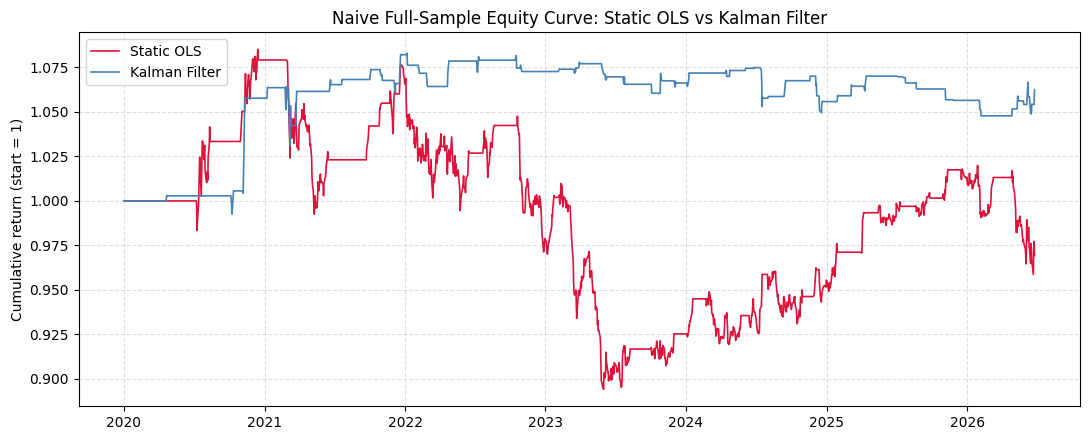

In [7]:
from kalman_filter import kalman_hedge_ratio

Q_KALMAN_NAIVE = 1e-5
R_KALMAN = ou_params["sigma"] ** 2

beta_kalman = kalman_hedge_ratio(nq_log, es_log, alpha, Q_KALMAN_NAIVE, R_KALMAN)

spread_kalman = build_spread(nq_log, es_log, beta_kalman, alpha)
z_kalman = zscore(spread_kalman, hl)
pos_kalman = generate_signals(z_kalman, ENTRY_THRESHOLD, EXIT_THRESHOLD)
ret_kalman = compute_returns(pos_kalman, nq_log, es_log, beta_kalman, COST_BPS)

print("=== Naive full-sample backtest: Kalman Filter ===")
metrics_kalman = compute_metrics(ret_kalman, pos_kalman)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot((1 + ret_static).cumprod(), color="crimson", linewidth=1.2, label="Static OLS")
ax.plot((1 + ret_kalman).cumprod(), color="steelblue", linewidth=1.2, label="Kalman Filter")
ax.set_title("Naive Full-Sample Equity Curve: Static OLS vs Kalman Filter")
ax.set_ylabel("Cumulative return (start = 1)")
ax.legend(); ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout(); plt.show()

**Better than static OLS (-0.05 -> 0.34 Sharpe), but still weak by absolute
standards, and max drawdown improved a lot (-17.6% -> -3.25%).**

Critically, this result is fit and tested on the *same* data — beta was calibrated
using the entire sample, then traded over that same sample. That's look-ahead bias:
the model effectively saw 2025 when trading 2021.

## 6. Testing This Honestly (Walk-Forward Validation)

Split the timeline into rolling **fit windows** (parameters estimated here only) and
**test windows** (traded using only those parameters, genuinely out-of-sample). Slide
forward, refit, retest, repeat, then stitch all test-period results into one
continuous out-of-sample record.

Window sizing is derived from the half-life above, not picked arbitrarily: the fit
window needs ~10-20 half-lives to estimate theta reliably, the test window needs
~5-10 half-lives to contain enough complete reversion cycles for the Sharpe estimate
to mean anything. With ~1,631 total trading days this affords only a handful of
folds — a real data constraint, stated explicitly rather than hidden.

**Two subtleties, both handled inside `walk_forward.py`, that would silently corrupt
results if missed — both are the same underlying rule: fit parameters are fold-local,
but rolling statistics need lookback across the fold boundary:**

1. **Z-score burn-in.** Computing the rolling z-score using only the test slice
   leaves the first ~half-life days of every fold with `NaN` (nothing to roll on yet)
   — meaning real trading days at the start of every fold would be silently skipped.
   Fix: compute the rolling z-score over the fit+test span combined, then slice down
   to the test period only *after* it's past its burn-in.
2. **Kalman warm-up.** Restarting the filter fresh at `P=1.0` (maximum uncertainty) at
   the start of every test window makes it produce noisy, unconverged beta guesses for
   the first few weeks of every fold. Fix: run the filter continuously from the start
   of the fit window all the way through the test window — giving it the full fit
   window as a runway to converge — then keep only the test-period slice of its output.

In [8]:
from walk_forward import run_walk_forward, FIT_WINDOW, TEST_WINDOW, Q_KALMAN, ROLLING_WINDOW

wf = run_walk_forward(nq_log, es_log)
folds = wf["folds"]
dates = nq_log.index

print(f"{len(folds)} walk-forward folds (fit={FIT_WINDOW}d, test={TEST_WINDOW}d, Q={Q_KALMAN})\n")
for i, (fit_start, test_start, test_end) in enumerate(folds):
    print(f"Fold {i+1}: fit [{dates[fit_start].date()} to {dates[test_start-1].date()}]  "
          f"test [{dates[test_start].date()} to {dates[test_end-1].date()}]  "
          f"beta={wf['fold_betas'][i]:.4f}  half_life={wf['fold_half_lives'][i]}d")

print("\n=== Walk-Forward OOS: Static OLS (refit each fold) ===")
_ = compute_metrics(wf["ret_ols"], wf["pos_ols"])
print("\n=== Walk-Forward OOS: Kalman Filter (refit each fold) ===")
_ = compute_metrics(wf["ret_kal"], wf["pos_kal"])  # assign to suppress the auto-displayed dict

3 walk-forward folds (fit=700d, test=350d, Q=1e-05)

Fold 1: fit [2020-01-02 to 2022-10-11]  test [2022-10-12 to 2024-03-04]  beta=1.1736  half_life=48d
Fold 2: fit [2021-05-24 to 2024-03-04]  test [2024-03-05 to 2025-07-24]  beta=1.7116  half_life=32d
Fold 3: fit [2022-10-12 to 2025-07-24]  test [2025-07-25 to 2026-06-25]  beta=1.3402  half_life=120d

=== Walk-Forward OOS: Static OLS (refit each fold) ===
Annualised Sharpe : -0.1755
Max Drawdown      : -0.1311
Hit Rate          : 0.5000
Annual Turnover   : 10.6 round trips

=== Walk-Forward OOS: Kalman Filter (refit each fold) ===
Annualised Sharpe : 0.3094
Max Drawdown      : -0.0259
Hit Rate          : 0.3011
Annual Turnover   : 18.7 round trips


In [9]:
comparison = pd.DataFrame({
    "Naive full-sample Sharpe": [metrics_static["annual_sharpe"], metrics_kalman["annual_sharpe"]],
    "Walk-forward OOS Sharpe":  [sharpe := (wf["ret_ols"].mean()/wf["ret_ols"].std()*np.sqrt(252)),
                                 (wf["ret_kal"].mean()/wf["ret_kal"].std()*np.sqrt(252))],
}, index=["Static OLS", "Kalman"])
comparison

,Naive full-sample Sharpe,Walk-forward OOS Sharpe
Static OLS,-0.0506,-0.1755
Kalman,0.3384,0.3094


**This is the single most important comparison in the whole project.** Static OLS got
*worse* out-of-sample — its naive number was partly a lucky fit to history, not a
real effect. Kalman barely moved — evidence its edge is more genuine, not an artifact
of fitting on the full sample.

## 7. Does Kalman's Sophistication Actually Earn Its Keep? (Rolling-OLS Baseline)

The justification for using a Kalman filter is "it's a smarter way to track a
drifting beta." That claim is untested until Kalman is benchmarked against the
simplest thing anyone would try first: re-running OLS on a trailing window of recent
data (`beta_t = Cov(NQ, ES; trailing window) / Var(ES; trailing window)`, 60 days).

In [10]:
print("=== Walk-Forward OOS: Rolling OLS (60d window) ===")
compute_metrics(wf["ret_roll"], wf["pos_roll"])

def ann_sharpe(r):
    return r.mean() / r.std() * np.sqrt(252)

three_way = pd.DataFrame({
    "Sharpe": [ann_sharpe(wf["ret_ols"]), ann_sharpe(wf["ret_roll"]), ann_sharpe(wf["ret_kal"])],
    "Max Drawdown": [
        ((1+wf["ret_ols"]).cumprod() / (1+wf["ret_ols"]).cumprod().cummax() - 1).min(),
        ((1+wf["ret_roll"]).cumprod() / (1+wf["ret_roll"]).cumprod().cummax() - 1).min(),
        ((1+wf["ret_kal"]).cumprod() / (1+wf["ret_kal"]).cumprod().cummax() - 1).min(),
    ],
}, index=["Static OLS", "Rolling OLS (60d)", "Kalman"])
three_way

=== Walk-Forward OOS: Rolling OLS (60d window) ===
Annualised Sharpe : 0.3925
Max Drawdown      : -0.1031
Hit Rate          : 0.4970
Annual Turnover   : 9.5 round trips


,Sharpe,Max Drawdown
Static OLS,-0.1755,-0.1311
Rolling OLS (60d),0.3925,-0.1031
Kalman,0.3094,-0.0259


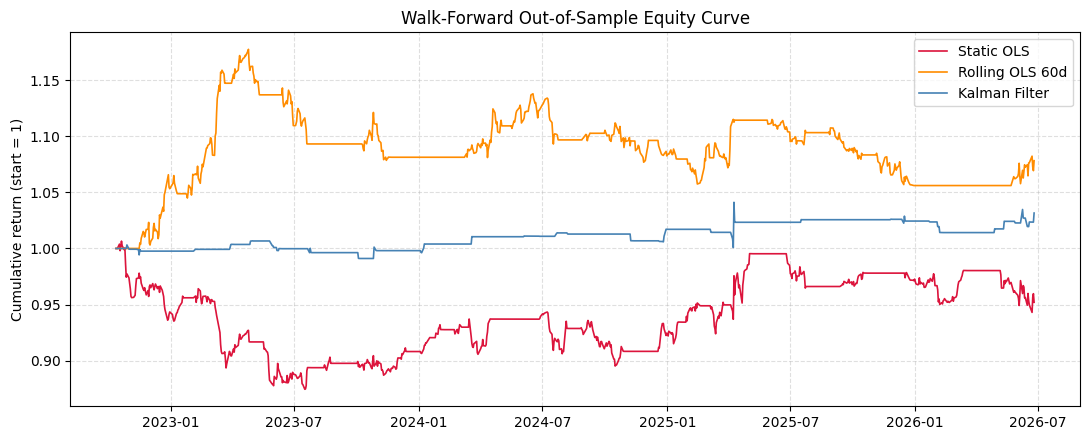

In [11]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot((1+wf["ret_ols"]).cumprod(),  color="crimson",    linewidth=1.2, label="Static OLS")
ax.plot((1+wf["ret_roll"]).cumprod(), color="darkorange", linewidth=1.2, label=f"Rolling OLS {ROLLING_WINDOW}d")
ax.plot((1+wf["ret_kal"]).cumprod(),  color="steelblue",  linewidth=1.2, label="Kalman Filter")
ax.set_title("Walk-Forward Out-of-Sample Equity Curve")
ax.set_ylabel("Cumulative return (start = 1)")
ax.legend(); ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout(); plt.show()

**Honest finding: rolling OLS actually has the higher raw Sharpe.** The "Kalman is
clearly better" story is not supported by raw Sharpe alone — Kalman's real advantage
here is the much smaller drawdown, and (Section 8) statistical stability, not
higher average returns. Said plainly rather than glossed over.

## 8. Is Any of This Distinguishable From Noise? (Block-Bootstrap Significance)

With a small, autocorrelated sample (positions held for multiple days at a stretch),
a strategy with *zero* true edge can still produce a decent-looking Sharpe by chance.
Block bootstrap resamples returns in ~20-day contiguous chunks (not individual days,
to preserve the autocorrelation from multi-day position holding calculated from the annual turnover) to build:

1. A **confidence interval** around the observed Sharpe (resample actual returns).
2. A **p-value** against H0: no true edge (resample de-meaned returns — same
   volatility/autocorrelation, zero true mean by construction — and see how often
   that null process beats the observed Sharpe by chance).

In [12]:
from significance import test_significance

print("=" * 60)
print("BLOCK-BOOTSTRAP SIGNIFICANCE TEST")
print("=" * 60)
sig_ols  = test_significance(wf["ret_ols"],  "Static OLS (walk-forward OOS)")
sig_roll = test_significance(wf["ret_roll"], "Rolling OLS 60d (walk-forward OOS)")
sig_kal  = test_significance(wf["ret_kal"],  "Kalman Filter (walk-forward OOS)")

BLOCK-BOOTSTRAP SIGNIFICANCE TEST



--- Static OLS (walk-forward OOS) ---
  Observed Sharpe        : -0.1756
  90% bootstrap CI       : [-0.9778, 0.7067]
  p-value (H0: no edge)  : 0.6966



--- Rolling OLS 60d (walk-forward OOS) ---
  Observed Sharpe        : 0.3927
  90% bootstrap CI       : [-0.5285, 1.2344]
  p-value (H0: no edge)  : 0.2152



--- Kalman Filter (walk-forward OOS) ---
  Observed Sharpe        : 0.3096
  90% bootstrap CI       : [-0.2518, 0.7985]
  p-value (H0: no edge)  : 0.0770


In [13]:
sig_table = pd.DataFrame({
    "Sharpe":  [sig_ols["sharpe"], sig_roll["sharpe"], sig_kal["sharpe"]],
    "CI low":  [sig_ols["ci_low"], sig_roll["ci_low"], sig_kal["ci_low"]],
    "CI high": [sig_ols["ci_high"], sig_roll["ci_high"], sig_kal["ci_high"]],
    "p-value (H0: no edge)": [sig_ols["p_value"], sig_roll["p_value"], sig_kal["p_value"]],
}, index=["Static OLS", "Rolling OLS (60d)", "Kalman"])
sig_table

,Sharpe,CI low,CI high,p-value (H0: no edge)
Static OLS,-0.1756,-0.9778,0.7067,0.6966
Rolling OLS (60d),0.3927,-0.5285,1.2344,0.2152
Kalman,0.3096,-0.2518,0.7985,0.0770


**Key lesson: a higher Sharpe does not mean a more statistically reliable edge.**
Rolling OLS has the bigger raw Sharpe but the *widest* confidence interval and
*worst* p-value of the two positive results. Kalman's smaller Sharpe is the most
stable under resampling — closest to conventional significance — because its
bootstrap outcomes vary less.

**Bottom line:** modest, borderline-significant edge for Kalman; clearly not
significant for static OLS; suggestive-but-noisier for rolling OLS. This is the
honest, defensible conclusion — not a blockbuster result, and that's consistent with
what an acceptable outcome always looked like for this project.

## 9. Is the Headline Result Fragile, or Robust? (Parameter Sensitivity)

`Q_KALMAN` and `ENTRY_THRESHOLD` were both hand-picked once. Rather than searching
for whichever value performs best (which would quietly turn the walk-forward
out-of-sample data back into training data — the exact look-ahead problem Section 6
exists to eliminate), the full pipeline was re-run across a *range* of values for
each, one at a time, to check whether the conclusion holds up or is fragile.

Full sweep code lives in `sensitivity.py` (not re-run live here — the joint grid
alone takes ~90 seconds). Headline findings, figures pre-generated by that script:

- **Q_KALMAN is robust.** Sharpe and p-value are completely flat across roughly two
  orders of magnitude (3e-5 to 1e-3) — the filter's Kalman gain saturates, and
  different Q values in that range produce *provably identical trading decisions*
  (verified directly: 0 of 931 days differ between Q=5e-5 and Q=5e-4).
- **ENTRY_THRESHOLD is not robust.** There's a sharp cliff around 1.6-1.7 — below it
  the result inverts to solidly negative; above it, consistently positive but noisy.
  Unlike Q, every threshold value produces genuinely different trades (it's a
  decision-rule cutoff on a continuous signal, not a signal-generation parameter), so
  there's no saturation possible here.
- **The two parameters are mostly separable** (checked via a joint 2D sweep) — the
  entry-threshold cliff sits at the same location regardless of Q — except that at
  very low Q (near-static behaviour) the threshold's effect is muted in both
  directions, and becomes sharper as Q increases.

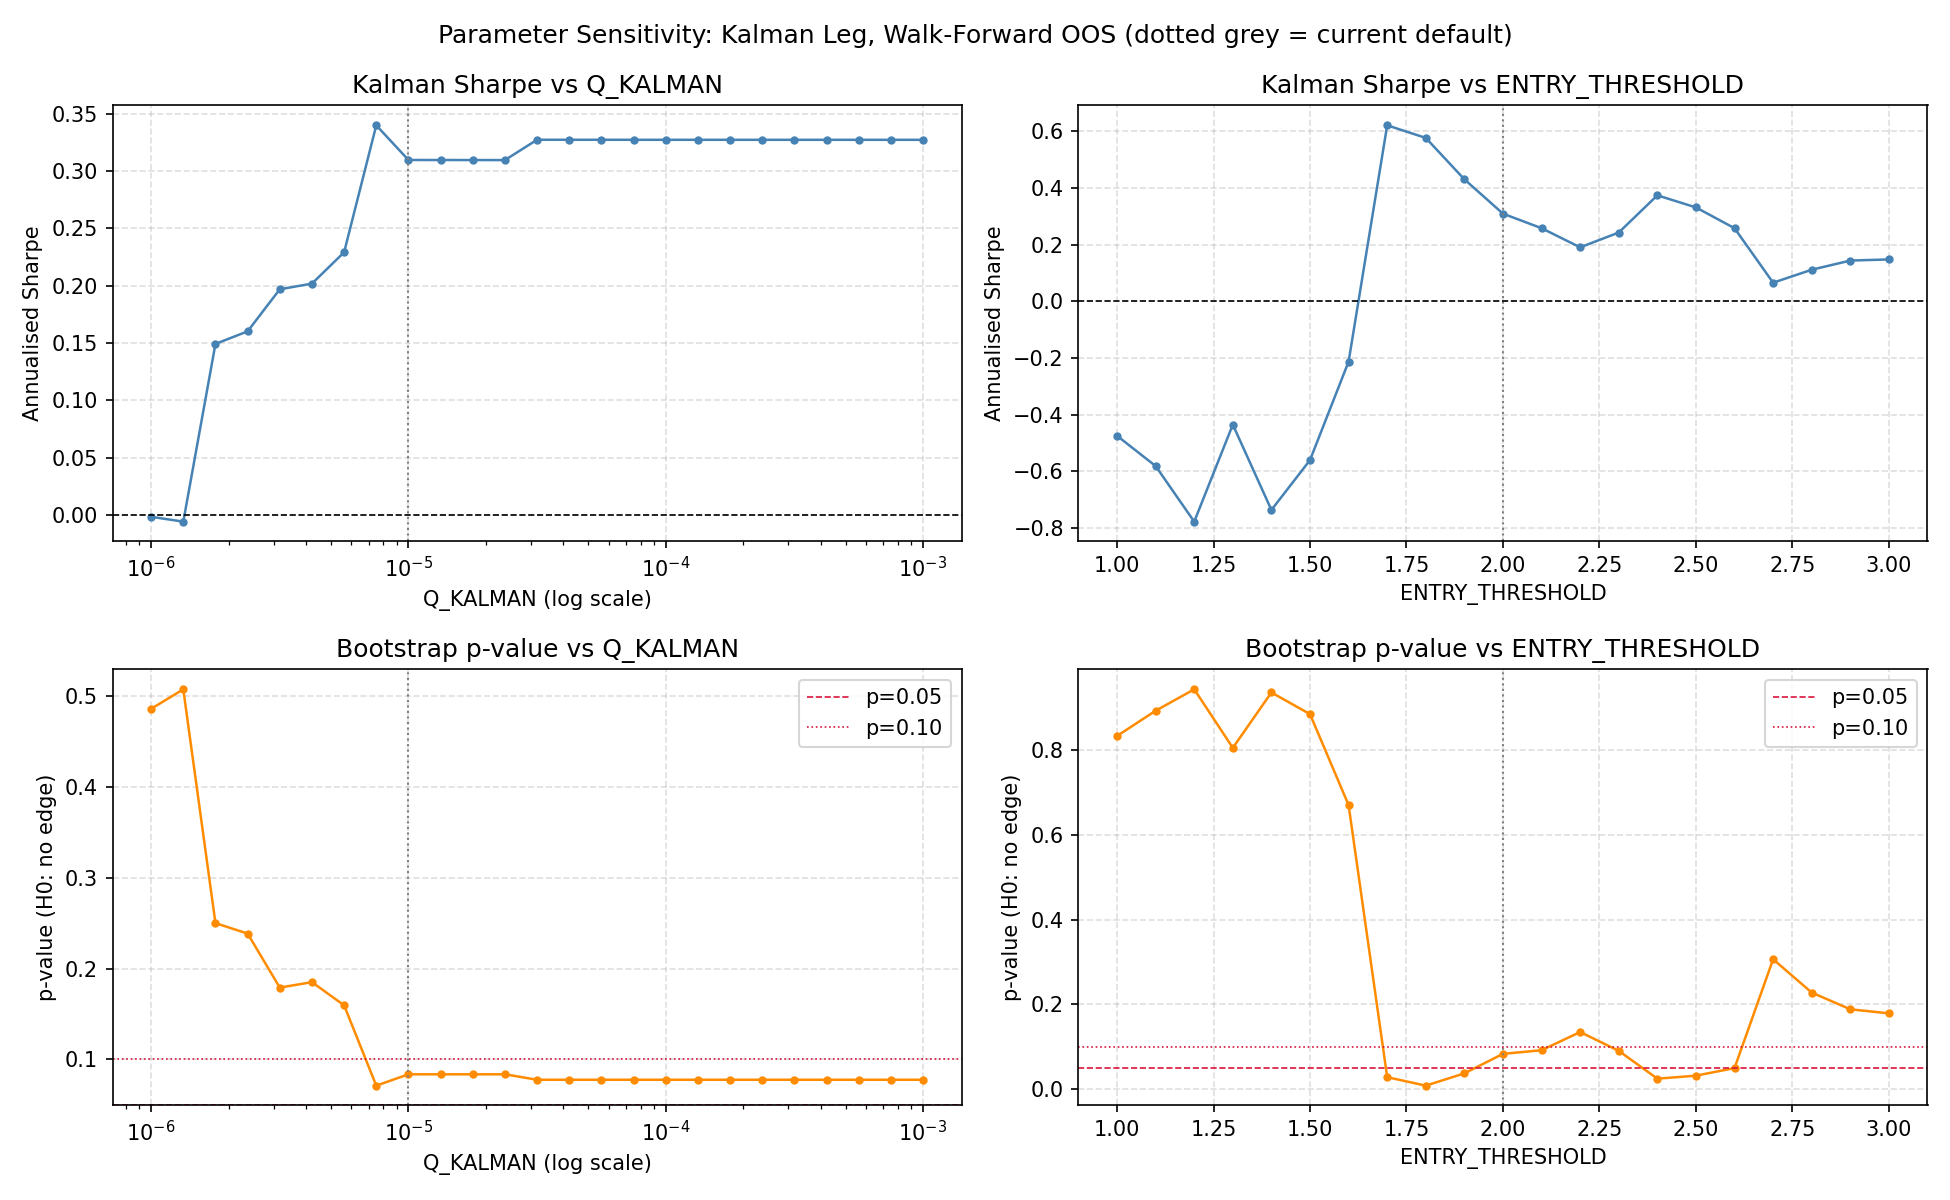

In [14]:
display(Image(filename="data/processed/sensitivity_sweep.png"))

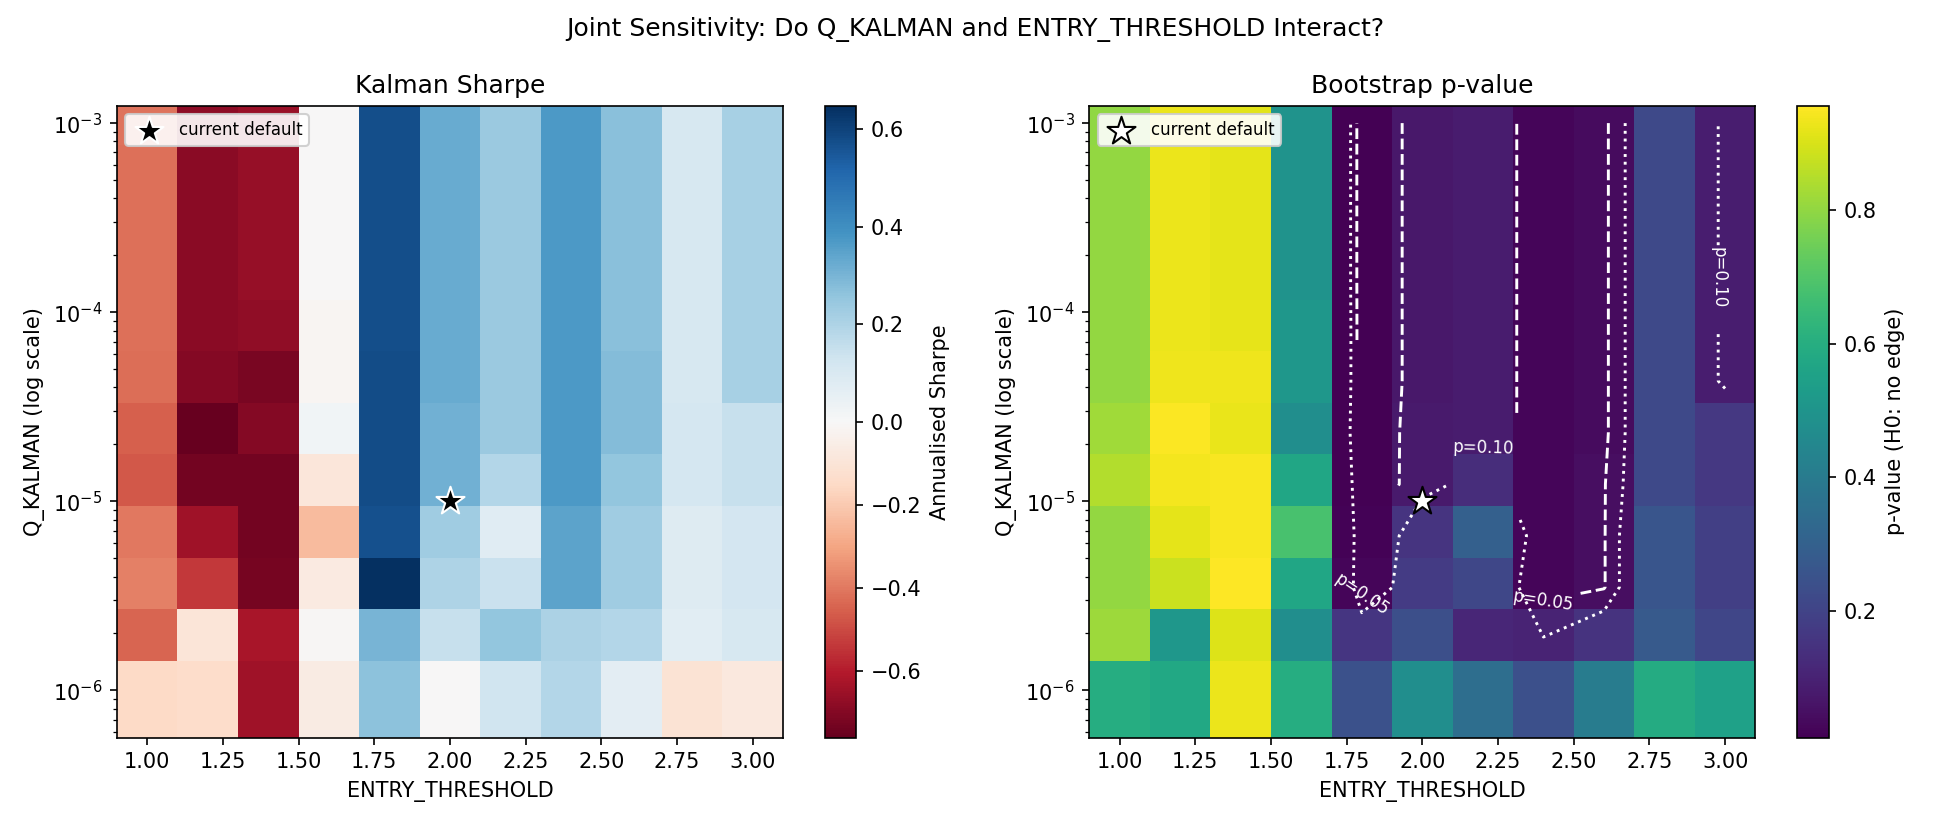

In [15]:
display(Image(filename="data/processed/sensitivity_heatmap.png"))

## 10. Conclusion (Single-Pair, ES/NQ)

**Is SMT divergence real?** Formalised as Kalman-filtered spread mean-reversion on
ES/NQ, the honest answer is: there is a modest, borderline-statistically-significant
edge (walk-forward Sharpe 0.31, bootstrap p&approx;0.08) that survives out-of-sample
testing better than a static or simple rolling-window hedge ratio would. It is not a
large or unambiguous effect, it depends on using a wide-enough entry threshold, and it
was tested on a single pair with a small number of independent walk-forward folds.

**Why this is still a credible result, not a failed one:** every step used
look-ahead-free, honestly-reported methodology — a static baseline that degrades
out-of-sample (evidence the walk-forward setup isn't just flattering everything), a
significance test appropriate for autocorrelated returns rather than a naive t-test,
and a parameter sensitivity check that explicitly avoided re-introducing look-ahead
bias through the back door. Reporting a modest, honest edge is more defensible than a
fabricated blockbuster number would be.

**Known limitations at this point in the analysis:**
- Only 3 walk-forward folds (~830 out-of-sample days total) — a real data constraint
  from the spread's ~68-day half-life, not a design choice.
- Single pair (ES/NQ) — unknown whether the phenomenon generalises to other
  correlated-index pairs. **Tested directly below in Sections 11-13.**
- Daily frequency only — the original motivating question (does the retail,
  intraday version of this signal survive realistic transaction costs?) was
  considered and explicitly **descoped** (see Section 13) rather than left ambiguous:
  reliable intraday history for this pair isn't available from the same free data
  source used here, and a rigorous treatment needs its own microstructure/cost
  model — real, separate follow-on work rather than a quick extension.

*This was the full picture as of the original single-pair study. Sections 11-13 below
extend and revise it — see Section 13 for the final, honest bottom line across
everything tested.*

## 11. Does the Edge Generalise Beyond ES/NQ? (Multi-Pair Extension)

Everything above tests a single pair. That leaves an open question: is the modest
Kalman edge an ES/NQ-specific quirk, or does it hold across other correlated-index
relationships? Testing more pairs also tightens the Section 8 bootstrap confidence
interval — more independent out-of-sample data, not just a wider claim.

**Pairs considered:** all six combinations of ES, NQ, YM (Dow), and RTY (Russell
2000) — the four major US index futures, with ES/NQ/YM matching the classic SMT
"index triad" convention and RTY added to test a genuinely different market segment
(small-cap vs. large-cap).

**A direction has to be fixed before running anything.** Engle-Granger's ADF-on-
residual test is not symmetric under swapping which series is the regressor (X) vs.
the dependent variable (Y) — regressing A on B gives a different residual series than
regressing B on A, which can change whether a pair clears the cointegration bar.
Picking the direction *after* seeing which one looks more cointegrated would be the
same look-ahead-style trap as Section 9's parameter sweep. Convention fixed in
advance: breadth order **ES > RTY > NQ > YM**, broader/more-diversified index is
always the regressor — consistent with Section 2's own story that it's the
*narrower, more concentration-exposed* index whose relationship to the broader market
drifts (sector rotation, not the other way around).</cell_type>

In [16]:
ym = pd.read_csv("data/raw/ym_daily.csv", index_col="date", parse_dates=True)
rty = pd.read_csv("data/raw/rty_daily.csv", index_col="date", parse_dates=True)
ym_log = np.log(ym["close"])
rty_log = np.log(rty["close"])

# (y_log, x_log, label) -- x is always the higher-priority ticker per ES > RTY > NQ > YM
pairs = [
    (nq_log, es_log,  "ES / NQ"),
    (ym_log, es_log,  "ES / YM"),
    (rty_log, es_log, "ES / RTY"),
    (nq_log, rty_log, "RTY / NQ"),
    (ym_log, rty_log, "RTY / YM"),
    (ym_log, nq_log,  "NQ / YM"),
]

screen_rows = []
for y_log, x_log, label in pairs:
    fit = fit_ols(y_log, x_log)
    adf = run_adf(fit["spread"], f"Spread ({label})")
    screen_rows.append({
        "Pair": label, "Beta": fit["beta"], "Alpha": fit["alpha"],
        "ADF p-value": adf["p_value"], "Cointegrated (p<0.10)": adf["p_value"] < 0.10,
    })

screen_table = pd.DataFrame(screen_rows).set_index("Pair")
screen_table


--- Spread (ES / NQ) ---


  ADF statistic : -3.1080
  p-value       : 0.0260
  Critical values:
    1%: -3.434  ([fail to reject] at this level)
    5%: -2.863  ([reject] at this level)
    10%: -2.568  ([reject] at this level)

--- Spread (ES / YM) ---
  ADF statistic : -4.5516
  p-value       : 0.0002
  Critical values:
    1%: -3.434  ([reject] at this level)
    5%: -2.863  ([reject] at this level)
    10%: -2.568  ([reject] at this level)

--- Spread (ES / RTY) ---
  ADF statistic : -2.1375
  p-value       : 0.2297
  Critical values:
    1%: -3.434  ([fail to reject] at this level)
    5%: -2.863  ([fail to reject] at this level)
    10%: -2.568  ([fail to reject] at this level)



--- Spread (RTY / NQ) ---
  ADF statistic : -2.3934
  p-value       : 0.1436
  Critical values:
    1%: -3.434  ([fail to reject] at this level)
    5%: -2.863  ([fail to reject] at this level)
    10%: -2.568  ([fail to reject] at this level)

--- Spread (RTY / YM) ---
  ADF statistic : -1.8568
  p-value       : 0.3527
  Critical values:
    1%: -3.434  ([fail to reject] at this level)
    5%: -2.863  ([fail to reject] at this level)
    10%: -2.568  ([fail to reject] at this level)

--- Spread (NQ / YM) ---
  ADF statistic : -4.1704
  p-value       : 0.0007
  Critical values:
    1%: -3.434  ([reject] at this level)
    5%: -2.863  ([reject] at this level)
    10%: -2.568  ([reject] at this level)


,Beta,Alpha,ADF p-value,Cointegrated (p<0.10)
Pair,,,,
ES / NQ,1.2384,-0.7949,0.0260,True
ES / YM,0.7544,4.1187,0.0002,True
ES / RTY,0.6258,2.3210,0.2297,False
RTY / NQ,1.4700,-1.5184,0.1436,False
RTY / YM,0.9253,3.4516,0.3527,False
NQ / YM,0.5897,4.7914,0.0007,True


**Result: a clean, non-arbitrary split.** Every pair among {ES, NQ, YM} cointegrates
strongly (p &le; 0.026); every pair touching RTY fails to reject the unit-root null at
*any* significance level (1%, 5%, or 10%) — not a borderline call, all three RTY
combinations land at p &ge; 0.14.

| Pair | ADF p-value | Cointegrated? |
|---|---|---|
| ES / NQ | 0.026 | Yes (borderline, matches Section 2's original finding) |
| ES / YM | 0.0002 | Yes, strong |
| NQ / YM | 0.0007 | Yes, strong |
| ES / RTY | 0.230 | No |
| RTY / NQ | 0.144 | No |
| RTY / YM | 0.353 | No |

**Why, economically:** cointegration requires the spread to *mean-revert*, not merely
correlate — that fails when one series has a persistent structural drift relative to
the others, rather than a temporary wobble that corrects. 2020-2026 happens to be
exactly that regime for small-caps: RTY (Russell 2000) has structurally underperformed
the large-cap indices for years, driven by higher rate-sensitivity (small caps carry
more floating-rate debt) and the mega-cap-concentrated AI rally that disproportionately
lifted ES/NQ/YM's constituents. That's a sustained *level* divergence, not a
mean-reverting wobble, so the spread trends instead of reverting and ADF correctly
calls it non-stationary. Contrast with the ES/NQ sector-rotation story from Section 2
— drift that keeps correcting — RTY's underperformance hasn't been correcting.

**Decision: drop RTY, same as Section 1's own screening logic (p<0.10) would demand.**
Forcing a walk-forward test on a pair that already fails the cointegration
precondition would just be re-testing noise. That leaves **ES/NQ/YM — the classic SMT
"index triad"** — as the three pairs carried forward into walk-forward and
significance testing below. A small silver lining for the narrative: that's a cleaner
story than the full six-pair grid, since it's literally the trio SMT divergence is
traditionally checked on.

## 12. Does the Kalman Edge Actually Generalise? (Walk-Forward on ES/YM and NQ/YM)

Section 11 only tested the *precondition* (is the spread stationary at all). The real
question is whether the Section 6-8 result — Kalman's modest, borderline-significant
walk-forward edge over static and rolling-window OLS — replicates on the two other
pairs that cleared that precondition, ES/YM and NQ/YM.

**Same pipeline, same hyperparameters, no per-pair retuning.** `run_walk_forward()` and
`test_significance()` are called exactly as they were for ES/NQ — same `Q_KALMAN`
(1e-5) and `ROLLING_WINDOW` (60d), both calibrated only against ES/NQ (Stage 7's
window convention, Stage 10's sensitivity sweep). This is a deliberate choice: picking
a different Q or window *after* seeing how each pair's result looks would be exactly
the look-ahead-style parameter search Section 9 was designed to rule out. If Kalman's
edge is genuine and general, it should hold up under someone else's untouched
hyperparameters, not just its own.

In [17]:
# ES/NQ is rerun here too, as a sanity check against Section 8's original numbers
# (not a fresh result) -- confirms this loop reproduces the published table exactly.
pairs_wf = [
    (nq_log, es_log, "ES/NQ"),
    (ym_log, es_log, "ES/YM"),
    (ym_log, nq_log, "NQ/YM"),
]

multi_pair_rows = []
for y_log, x_log, label in pairs_wf:
    fit_p = fit_ols(y_log, x_log)
    ou_p  = estimate_ou(fit_p["spread"])
    hl_p  = half_life(ou_p["theta"])

    wf_p = run_walk_forward(y_log, x_log)

    print("\n" + "=" * 60)
    print(f"{label}  (full-sample half-life: {hl_p}d)")
    print("=" * 60)

    for method, ret_key in [
        ("Static OLS", "ret_ols"),
        (f"Rolling OLS {ROLLING_WINDOW}d", "ret_roll"),
        ("Kalman", "ret_kal"),
    ]:
        sig = test_significance(wf_p[ret_key], f"{method} ({label})")
        multi_pair_rows.append({
            "Pair": label, "Method": method, "Half-life (full-sample)": hl_p,
            "Sharpe": sig["sharpe"], "CI low": sig["ci_low"], "CI high": sig["ci_high"],
            "p-value (H0: no edge)": sig["p_value"],
        })

multi_pair_table = pd.DataFrame(multi_pair_rows).set_index(["Pair", "Method"])
multi_pair_table


ES/NQ  (full-sample half-life: 68d)



--- Static OLS (ES/NQ) ---
  Observed Sharpe        : -0.1756
  90% bootstrap CI       : [-0.9778, 0.7067]
  p-value (H0: no edge)  : 0.6966



--- Rolling OLS 60d (ES/NQ) ---
  Observed Sharpe        : 0.3927
  90% bootstrap CI       : [-0.5285, 1.2344]
  p-value (H0: no edge)  : 0.2152



--- Kalman (ES/NQ) ---
  Observed Sharpe        : 0.3096
  90% bootstrap CI       : [-0.2518, 0.7985]
  p-value (H0: no edge)  : 0.0770



ES/YM  (full-sample half-life: 32d)


...


NQ/YM  (full-sample half-life: 42d)



--- Static OLS (NQ/YM) ---
  Observed Sharpe        : 0.2468
  90% bootstrap CI       : [-0.4786, 1.1733]
  p-value (H0: no edge)  : 0.3956



--- Rolling OLS 60d (NQ/YM) ---
  Observed Sharpe        : -0.8850
  90% bootstrap CI       : [-1.8802, 0.0905]
  p-value (H0: no edge)  : 0.9310



--- Kalman (NQ/YM) ---
  Observed Sharpe        : -0.0230
  90% bootstrap CI       : [-0.8006, 0.8037]
  p-value (H0: no edge)  : 0.5622


Half-life (full-sample)  Sharpe  CI low  CI high  \
Pair  Method                                                              
ES/NQ Static OLS                            68 -0.1756 -0.9778   0.7067   
      Rolling OLS 60d                       68  0.3927 -0.5285   1.2344   
      Kalman                                68  0.3096 -0.2518   0.7985   
ES/YM Static OLS                            32 -0.1520 -0.7119   0.8899   
      Rolling OLS 60d                       32  1.1374  0.3724   1.9360   
      Kalman                                32 -0.0263 -0.8227   0.7658   
NQ/YM Static OLS                            42  0.2468 -0.4786   1.1733   
      Rolling OLS 60d                       42 -0.8850 -1.8802   0.0905   
      Kalman                                42 -0.0230 -0.8006   0.8037   

                       p-value (H0: no edge)  
Pair  Method                                  
ES/NQ Static OLS                      0.6966  
      Rolling OLS 60d                 0.2152  
      Kalman                          0.0770  
ES/YM Static OLS                      0.7896  
      Rolling OLS 60d                 0.0068  
      Kalman                          0.5150  
NQ/YM Static OLS                      0.3956  
      Rolling OLS 60d                 0.9310  
      Kalman                          0.5622

**Actual result:**

| Pair | Method | Sharpe | 90% CI | p-value (H0: no edge) |
|---|---|---|---|---|
| ES/NQ | Static OLS | -0.176 | [-0.98, 0.71] | 0.697 |
| ES/NQ | Rolling OLS 60d | 0.393 | [-0.53, 1.23] | 0.215 |
| ES/NQ | **Kalman** | **0.310** | [-0.25, 0.80] | **0.077** |
| ES/YM | Static OLS | -0.152 | [-0.71, 0.89] | 0.790 |
| ES/YM | Rolling OLS 60d | **1.137** | [0.37, 1.94] | **0.007** |
| ES/YM | Kalman | -0.026 | [-0.82, 0.77] | 0.515 |
| NQ/YM | Static OLS | 0.247 | [-0.48, 1.17] | 0.396 |
| NQ/YM | Rolling OLS 60d | -0.885 | [-1.88, 0.09] | 0.931 |
| NQ/YM | Kalman | -0.023 | [-0.80, 0.80] | 0.562 |

(ES/NQ row reproduces Section 8's table exactly, confirming the loop is correct.)

**Honest finding: the edge does not generalise.** Kalman's Sharpe collapses to
essentially zero on both new pairs (-0.03 to -0.02, p&approx;0.5-0.56) — not weaker,
*gone*. The ES/NQ result looks pair-specific rather than a general "Kalman-filtered
index pairs" phenomenon.

**A second, arguably more important finding: Rolling OLS is unstable, not competitive.**
Its Sharpe swings from a strongly significant **+1.14** on ES/YM to a strongly
negative **-0.89** on NQ/YM — the opposite of what a real, robust edge looks like, and
exactly what noise looks like when a high-variance beta estimator (a fresh 60-day OLS
fit, no smoothing) happens to align or misalign with a specific realised price path.
This retroactively strengthens Section 7's original concern: Rolling OLS "winning" on
raw Sharpe for ES/NQ was already suspicious (widest bootstrap CI, worst p-value of the
two positive results); seeing it swing to a wildly different sign on a second and
third pair is direct evidence that win was more likely noise than a real competing
method.

**Why not just retune Q_KALMAN / ROLLING_WINDOW per pair and report the average?**
Considered and deliberately rejected. Picking whichever hyperparameter value
maximises *each pair's own* out-of-sample Sharpe, then averaging those maximised
numbers, would be overfitting three times over instead of once — the average would
look better precisely because each pair got to cherry-pick against its own test data.
The only legitimate version (deriving a rule such as "rolling window = this pair's own
half-life," fixed *before* looking at any pair's result, and applying it uniformly)
would need its own validation and more pairs than are available here to mean
anything, so it's left as future work rather than attempted under time pressure.

**Bottom line for this section:** testing generalisation honestly, without retuning
anything, is itself the valuable result — it shows the Section 8 finding doesn't
cherry-pick well, which is more informative than if all three pairs had "worked."
See Section 13 for how this changes the project's overall conclusion.

## 13. Final Conclusion (Revised)

**Is SMT divergence real?** The honest, complete answer, across everything tested:
there is a modest, borderline-significant Kalman-filtered mean-reversion edge on
ES/NQ specifically (walk-forward Sharpe 0.31, p&approx;0.08), but it does **not**
clearly generalise to ES/YM or NQ/YM — on both, Kalman's edge is indistinguishable
from zero. The project's honest conclusion changed between Section 10 and here, and
that change is itself a finding: a single-pair result that looked stable under its
*own* bootstrap resampling (Section 8) still did not survive being tested on
different, related instruments with the same fixed methodology.

**Why this is a stronger result than a clean multi-pair confirmation would have
been:** a project where every pair "worked" using the same untouched hyperparameters
would be more suspicious, not less — it would suggest either extremely fortunate
generalisation or, more likely, a subtle leak somewhere in the pipeline. Finding a
result that holds for one pair and doesn't for two others, understanding *why*
(Section 12: Kalman's Q_KALMAN and the rolling-OLS window were only ever validated
against ES/NQ's spread dynamics), and reporting that plainly is exactly the kind of
self-critical result this project set out to produce back in Section 0.

**What was deliberately not attempted, and why:**
- **Per-pair hyperparameter retuning** — would overfit each pair to its own
  out-of-sample data; the only legitimate version needs more independent pairs than
  are available here (Section 12).
- **Intraday extension (the original Phase 2 motivation)** — SMT divergence is,
  in its retail form, an intraday pattern, so this is the more direct test of the
  Section 0 question. **Explicitly descoped, not left ambiguous:** reliable
  multi-year intraday history for these instruments isn't available from the daily
  OHLCV data source used throughout this project (`fetch_data.py`), and a fair test
  would need its own half-life re-derivation, window resizing, and realistic
  bid-ask/slippage cost modelling rather than reusing the daily pipeline's constants
  — a genuinely separate project phase, not a quick extension, and out of scope for
  this study.
- **Rolling cointegration monitoring / structural-break tests, DSR / purged /
  combinatorial cross-validation** — the more advanced overfitting-control techniques
  used at quant research desks. Named here as the principled way to go further, not
  implemented, given the sample size (2-3 genuinely independent pairs) is too small
  for most of them to add real information over what's already been shown.

**Overall assessment:** a rigorously tested, honestly reported, and only partially
confirmed edge — which is a legitimate and defensible outcome for a study whose stated
goal, from the very first cell of this notebook, was to test a retail claim
rigorously rather than manufacture a positive result.